In [381]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [382]:
# Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

In [383]:
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

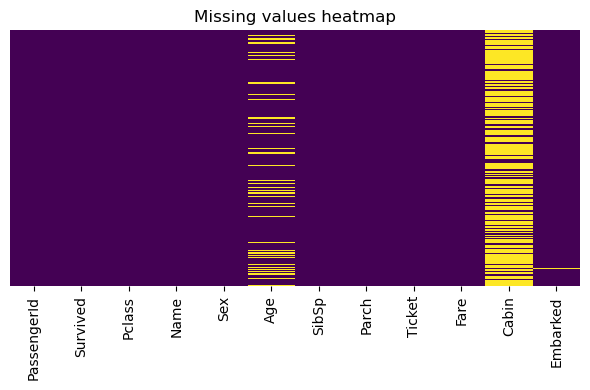

In [384]:
# visualizing missing values : 

plt.figure(figsize=(6,4))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing values heatmap')
plt.tight_layout()

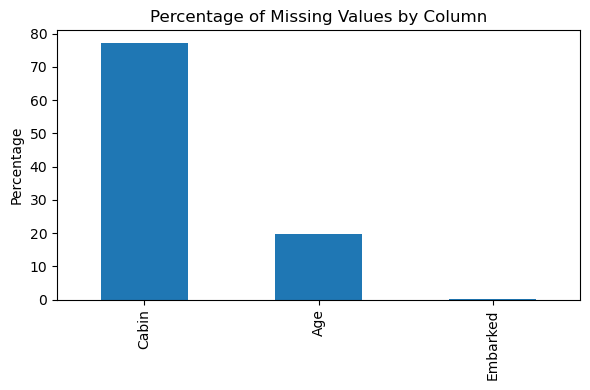

In [385]:
# Calculate percentage of  missing values per column
missing_percentage = titanic.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
plt.figure(figsize=(6,4))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

# HANDLING MISSING VALUES

In [386]:
titanic_reduced = titanic.drop(['Cabin', 'Ticket'],axis=1)

In [387]:
# Simple imputation for Age (using median grouped by Pclass)
age_imputed = titanic_reduced.copy()
age_imputed['Age'] = age_imputed.groupby('Pclass')['Age'].transform(lambda x : x.fillna(x.median()))

In [388]:
# Create missing indicator for age
age_imputed['Age_Missing'] = titanic_reduced['Age'].isnull().astype(int)

In [389]:
# Mode imputation for a categorical column (Embarked)
age_imputed['Embarked'] = age_imputed['Embarked'].fillna(age_imputed['Embarked'].mode()[0])

In [390]:
# verify imputation results 
age_imputed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64

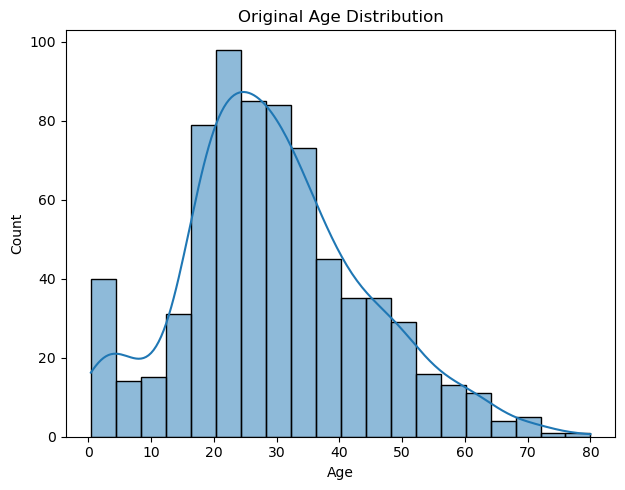

In [391]:
# Visualize Age column distribution before and after imputation
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(titanic['Age'].dropna(), kde=True)
plt.title('Original Age Distribution')
plt.tight_layout()
plt.show()

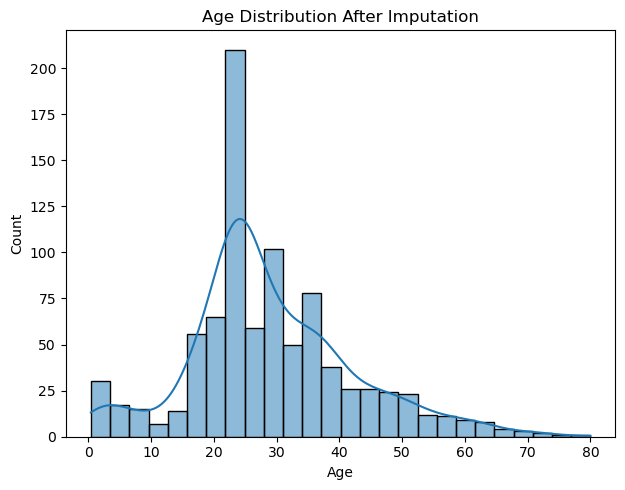

In [392]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.histplot(age_imputed['Age'], kde=True)
plt.title('Age Distribution After Imputation')
plt.tight_layout()
plt.show()

# FEATURE SCALING

In [393]:
# Select relevant columns and prepare a dataset for ML
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'
X = age_imputed[features]
y = age_imputed[target]

In [394]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [395]:
# Z-score Normalization
scaler = StandardScaler()
# Never directly transform your entire dataset, only fit on training data
numeric_features = ['Age', 'Fare']
X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_std[numeric_features] = scaler.transform(X_test[numeric_features])

In [396]:
# Min max scaler (Normalization)

min_max_scaler = MinMaxScaler()
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

X_train_norm[numeric_features] = min_max_scaler.fit_transform(X_train[numeric_features])
X_test_norm[numeric_features] = min_max_scaler.transform(X_test[numeric_features])

Text(0.5, 1.0, 'Original Fare Distribution')

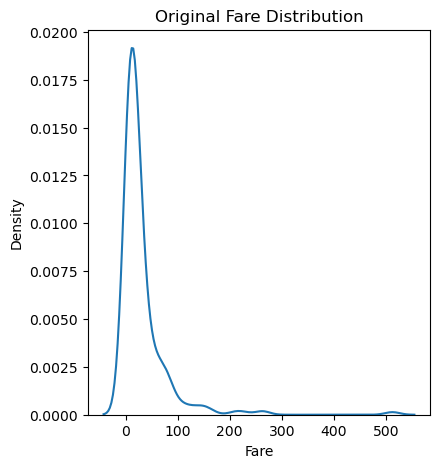

In [397]:
# Visualize scaling effects
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.kdeplot(X_train['Fare'], label='Original')
plt.title('Original Fare Distribution')

Text(0.5, 1.0, 'Standardized Fare')

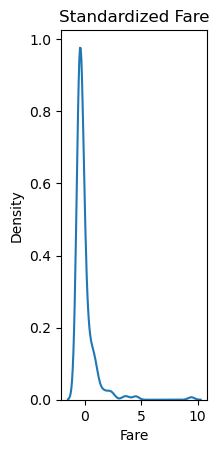

In [398]:
plt.subplot(1, 3, 2)
sns.kdeplot(X_train_std['Fare'], label='Standardized')
plt.title('Standardized Fare')

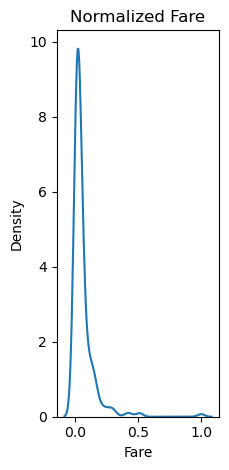

In [399]:
plt.subplot(1, 3, 3)
sns.kdeplot(X_train_norm['Fare'], label='Normalized')
plt.title('Normalized Fare')
plt.tight_layout()
plt.show()

# ENCODING CATEGORICAL VARIABLES

In [400]:
# 1. Label encoding for ordinal features
label_encoder = LabelEncoder()
X_train_encoded = X_train_std.copy()
X_test_encoded = X_test_std.copy()

In [401]:
# Apply Label Encoding for Sex Column
X_train_encoded['Sex'] = label_encoder.fit_transform(X_train_encoded['Sex'])
X_test_encoded['Sex'] = label_encoder.transform(X_test_encoded['Sex'])

In [402]:
# 2. One-Hot Encoding for nominal features
# Creating a one-hot encoder for 'Embarked'
embarked_ohe = OneHotEncoder(sparse_output=False, drop='first')
# Fit on training data
embarked_train_encoded = embarked_ohe.fit_transform(X_train_encoded[['Embarked']])
embarked_test_encoded = embarked_ohe.transform(X_test_encoded[['Embarked']])

In [403]:
# Create dataframes with the encoded columns 

embarked_train_df = pd.DataFrame(
    embarked_train_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_train_encoded.index
)

embarked_test_df = pd.DataFrame(
    embarked_test_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_test_encoded.index
)

In [404]:
# Drop original Embarked column and join encoded columns
X_train_encoded = X_train_encoded.drop('Embarked', axis=1).join(embarked_train_df)
X_test_encoded = X_test_encoded.drop('Embarked', axis=1).join(embarked_test_df)

In [405]:
# Compare Encoding Methods : 
print('Label Encoded SEX : ')
print(X_train_encoded['Sex'].value_counts())

Label Encoded SEX : 
Sex
1    410
0    213
Name: count, dtype: int64


In [406]:
print('One hot encoded Embarked : ')
print(X_train_encoded.filter(like='Embarked').head())

One hot encoded Embarked : 
     Embarked_Q  Embarked_S
445         0.0         1.0
650         0.0         1.0
172         0.0         1.0
450         0.0         1.0
314         0.0         1.0


# BUILDING PREPROCESSING PIPELINES

In [407]:
# Define preprocessing for numerical columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [408]:
# Define preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

In [409]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_features),
        ('cat', categorical_transformer, ['Sex', 'Embarked'])
])

In [410]:
# create a full pipeline with preprocessing and model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifire', LogisticRegression())
])

In [411]:
# Reset to use raw features for complete pipeline demonstration
X = age_imputed[features]
y = age_imputed[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [412]:
# Train the pipeline
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifire', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [413]:
predictions = model_pipeline.predict(X_test)

In [414]:
# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.7799

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



# ADVANCED: Custom Pipeline with Cross-Validation

In [415]:
# create a pipeline with multiple possible models

from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

In [416]:
# Define parameters to seach

param_grid = {
    'classifier__n_estimators' : [50,100],
    'classifier__max_depth' : [None, 10],
    'preprocessor__num__imputer__strategy' : ['mean', 'median'],
}

In [417]:
# Setup GridSearchCV

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [418]:
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'classifier__max_depth': [None, 10], 'classifier__n_estimators': [50, 100], 'preprocessor__num__imputer__strategy': ['mean', 'median']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [419]:
# Best params and score
print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best cross-validation score : {grid_search.best_score_:.4f}')

Best Parameters : {'classifier__max_depth': 10, 'classifier__n_estimators': 50, 'preprocessor__num__imputer__strategy': 'mean'}
Best cross-validation score : 0.7995


In [420]:
# Evaluate on Test Data
test_score = grid_search.score(X_test, y_test)
print(f'Test set score with best parameters : {test_score:.4f}')

Test set score with best parameters : 0.7575


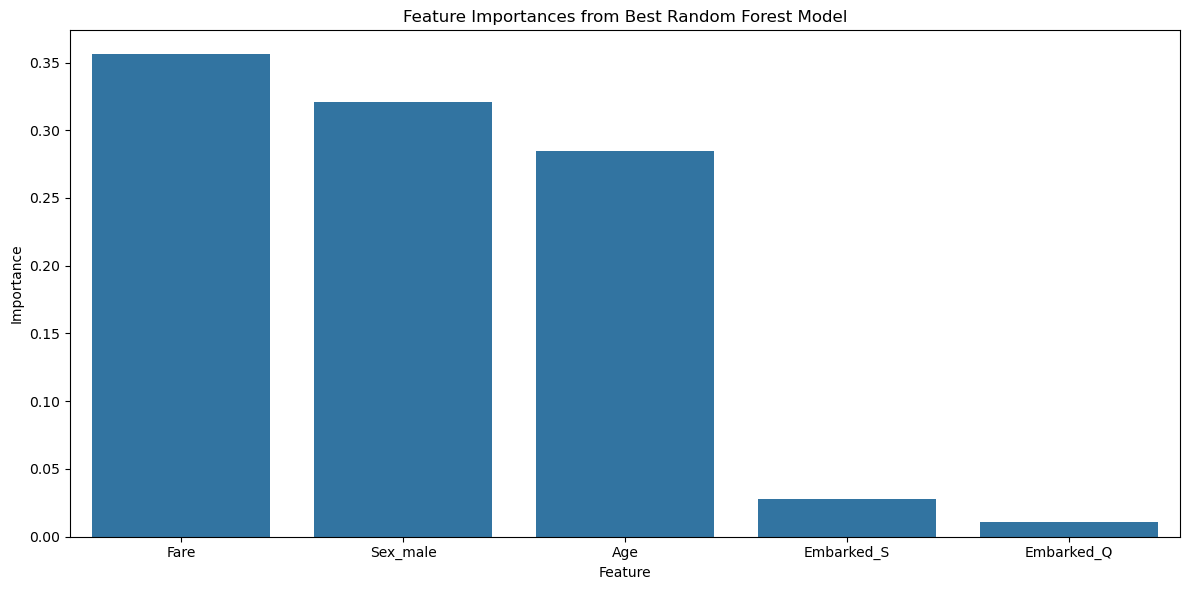

In [421]:
if hasattr(grid_search.best_estimator_.named_steps['classifier'], 'feature_importances_') : 
    # Get the preprocessor :  
    preprocessor = grid_search.best_estimator_.named_steps['preprocessor']
    # Get the feature names after transformation : 

    # The below line means that "Go inside the best model's preprocessing pipeline, access the categorical transformer, get the OneHotEncoder, 
    # and retrieve the names of the new encoded features."
    ohe_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(['Sex', 'Embarked'])
    
    feature_names = np.concatenate([numeric_features, ohe_features])

    # Get feature importances : 
    # This line extracts the feature importance scores from the best trained model (Random Forest). 
    importances = grid_search.best_estimator_.named_steps['classifier'].feature_importances_ 

    # Create a DF fror visualisation
    importance_df = pd.DataFrame({
        'Feature' : feature_names,
        'Importance' : importances
    }).sort_values('Importance', ascending=False)

    # Plot Feature Importance
    plt.figure(figsize=(12,6))
    sns.barplot(x='Feature', y='Importance', data=importance_df)
    plt.title('Feature Importances from Best Random Forest Model')
    plt.tight_layout()
    plt.show()

-----------------------------------------------

---------------------------------

# Exercise

## Week 3 Day 1 :  Titanic Data Preprocessing and Modeling

In this exercise you'll reinforce:

- **Missing‑value exploration & visualization**  
- **Imputation strategies** (deletion, group‑median, mode, missing indicator)  
- **Feature scaling** (StandardScaler vs MinMaxScaler)  
- **Categorical encoding** (LabelEncoder, OneHotEncoder)  
- **Building end‑to‑end pipelines** with `ColumnTransformer` + `Pipeline`  
- **Model training & evaluation** (LogisticRegression, RandomForest)  
- **Hyperparameter tuning** via `GridSearchCV`  
- **Feature importance** extraction  

> **Instructions:**  
> 1. Don’t modify cells above the first `# TODO`.  
> 2. Replace each `# TODO` with your code.  
> 3. Run cells sequentially and verify each output.  
> 4. Wherever requested, add a brief comment on what you observe.

In [422]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [423]:
# 1. Load the dataset
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)

In [424]:
# 1.2 How many missing values per column?
titanic_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

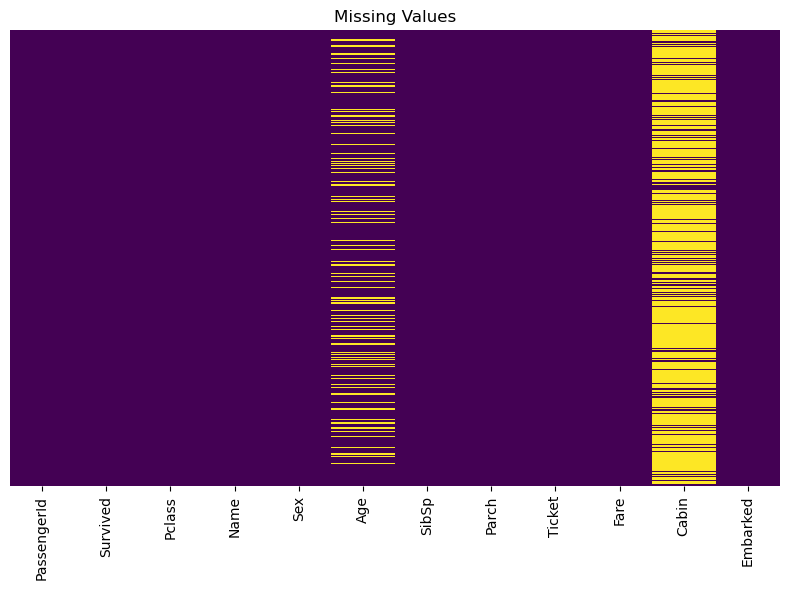

In [425]:
# 1.3 Visualize missingness with a heatmap
# TODO: use sns.heatmap(...) to show where data is missing

plt.figure(figsize=(8,6))
sns.heatmap(titanic_df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values')
plt.tight_layout()
plt.show()

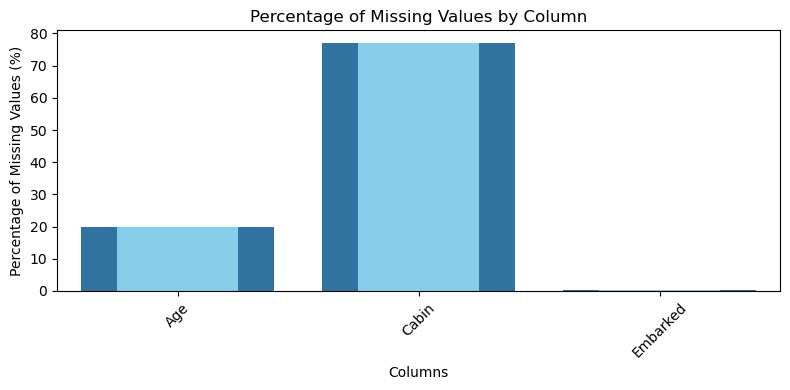

In [426]:
# 1.4 Percentage of missing values by column (bar plot)

# calcuate the percentage of missing values for each cols 
missing_percentage = titanic_df.isna().sum() / len(titanic_df) * 100
# keep only cols with missing values
missing_percentage = missing_percentage[missing_percentage > 0 ]
# Plot
plt.figure(figsize=(8,4))
sns.barplot(missing_percentage)
missing_percentage.plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Handle Missing Values

In [427]:
df = titanic_df.copy()

# 2.1 Drop columns with too many missing or irrelevant
df = df.drop('Cabin', axis=1)
# 2.2 Impute Age by median within each Pclass
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x : x.fillna(x.median()))
# 2.3 Create Age_missing indicator column
df['Missing_age'] = df['Age'].isna().astype(int)
# 2.4 Impute Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# 2.5 Verify no more missing values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Missing_age    0
dtype: int64

# Feature Scaling 

In [428]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

features = ['Age', 'Fare']
X = df[features]
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

# # 3.1 Standardization
# std = StandardScaler()
# # TODO: fit on X_train, transform both X_train and X_test
# X_train_std = std.fit_transform(X_train)
# X_test_std =  std.transform(X_test)


# Standardization
std = StandardScaler()

X_train_std = pd.DataFrame(
    std.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_std = pd.DataFrame(
    std.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# MinMaxScaler
mms = MinMaxScaler()

X_train_mms = pd.DataFrame(
    mms.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_mms = pd.DataFrame(
    mms.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# 3.2 Min‑Max normalization
# mms = MinMaxScaler()
# TODO: fit on X_train, transform both X_train and X_test
# X_train_mms = mms.fit_transform(X_train)
# X_test_mms = mms.transform(X_test)

Text(0.5, 1.0, 'Original Fare Distribution')

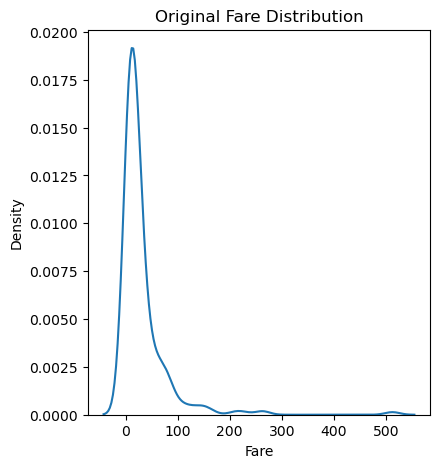

In [429]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.kdeplot(X_train['Fare'], label='original')
plt.title('Original Fare Distribution')

Text(0.5, 1.0, 'Standardized Fare Distribution')

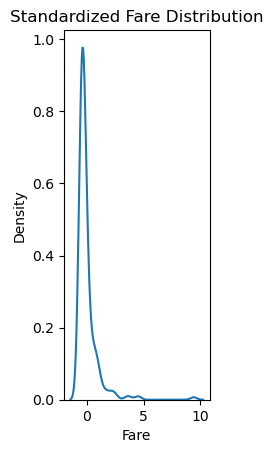

In [430]:
plt.subplot(1, 3, 2)
sns.kdeplot(X_train_std['Fare'], label='Standardized')
plt.title('Standardized Fare Distribution')

Text(0.5, 1.0, 'Normalized Fare Distribution')

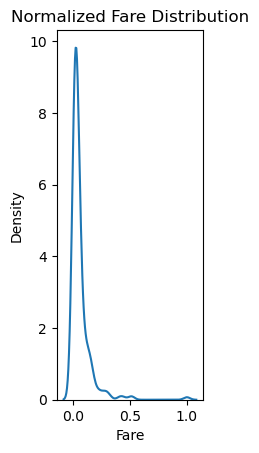

In [431]:
plt.subplot(1,3,3)
sns.kdeplot(X_train_mms['Fare'], label='Normalized')
plt.title('Normalized Fare Distribution')

# Encode Categorical Features 

In [432]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

X_cat = df[['Sex', 'Embarked']].copy()
# 4.1 Label‑encode Sex
le = LabelEncoder()
X_cat['Sex_le'] = le.fit_transform(X_cat['Sex'])

In [433]:
ohe = OneHotEncoder(sparse_output=False)
embarked_encoded = ohe.fit_transform(X_cat[['Embarked']])

embarked_df = pd.DataFrame(
    embarked_encoded,
    columns=ohe.get_feature_names_out(['Embarked']),
    index=X_cat.index
)

X_cat = pd.concat([X_cat, embarked_df],axis=1)

In [434]:
embarked_df

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
886,0.0,0.0,1.0
887,0.0,0.0,1.0
888,0.0,0.0,1.0
889,1.0,0.0,0.0


In [435]:
# Display your encoded features
# TODO: print head of resulting DataFrame
print(X_cat.head())

      Sex Embarked  Sex_le  Embarked_C  Embarked_Q  Embarked_S
0    male        S       1         0.0         0.0         1.0
1  female        C       0         1.0         0.0         0.0
2  female        S       0         0.0         0.0         1.0
3  female        S       0         0.0         0.0         1.0
4    male        S       1         0.0         0.0         1.0


# Build a Preprocessing + Model Pipeline

In [436]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [441]:
# Defining Transformers 

num_features = ['Age', 'Fare']
cat_features = ['Sex', 'Embarked']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scalar', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num',num_transformer,num_features),
    ('cat', cat_transformer, cat_features)
])

# 5.2 Create full pipeline with Logistic Regression
pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

# pipe = Pipeline([
#     ('preproc', preprocessor),
#     ('clf', RandomForestClassifier(random_state=42))
# ])


# 5.3 Split raw data and train
X_full = df[num_features + cat_features]
y_full = df['Survived']
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# TODO: fit pipe on X_tr, y_tr
pipe.fit(X_tr, y_tr)

# TODO: predict on X_te, compute accuracy and print classification_report
y_pred = pipe.predict(X_te)

accuracy = accuracy_score(y_te, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_te, y_pred))

Accuracy: 0.7799
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



#  Hyperparameter Tuning with GridSearchCV

Best Params: {'clf__max_depth': 10, 'clf__n_estimators': 100, 'preproc__num__imputer__strategy': 'mean'}
Best CV Score: 0.7962451612903226
Test Set Accuracy: 0.75


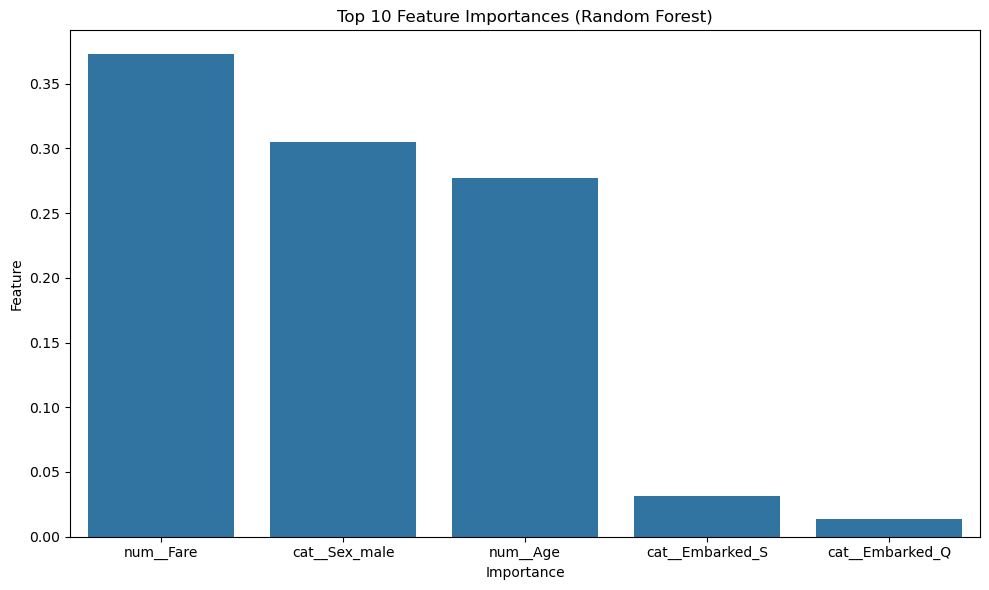

In [443]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 6.1 Replace classifier in pipeline
tune_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# 6.2 Set up parameter grid
param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 10],
    'preproc__num__imputer__strategy': ['mean','median']
}

grid = GridSearchCV(tune_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit grid on X_tr, y_tr
grid.fit(X_tr, y_tr)

# Print best_params_ and best_score_
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# 6.3 Evaluate best estimator on test set
test_score = grid.best_estimator_.score(X_te, y_te)
print("Test Set Accuracy:", test_score)

# 6.4 (Bonus) Extract and plot top 10 feature importances
best_rf = grid.best_estimator_.named_steps['clf']
feature_names = grid.best_estimator_.named_steps['preproc'].get_feature_names_out()

importances = pd.Series(best_rf.feature_importances_, index=feature_names)
top_10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10.index, y=top_10.values)
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()